<h1 align="center">Medical costs dataset</h1>

<h2 align="center">Introduction</h2>
<p>this dataset is known for being for regressions, thus, this will be my goal in this project, I am going to experiment and hopefully learn how to properly use a regression for predicting an output.<br>

<style>
  ol {
    list-style-type: none;
    counter-reset: item -1;
  }
  ol li {
    display: block;
  }
  ol li:before {
    content: counters(item, ".") " ";
    counter-increment: item;
    font-weight: bold;
  }
  ol ol {
    counter-reset: item 0;
  }
</style>

<ol>
  <li>Dataset pullup</li>
  <li>Data Visualisation <ol>
      <li>age graphics
       <ol>
          <li>Histogram of ages </li>
          <li>Histogram of ages by sex</li>
          <li>Histogram of ages by smoker status</li>
          <li>Histogram of ages by region</li>
       </ol>
      </li>
      <li> bmi graphics
        <ol>
          <li>Histogram of bmis </li>
          <li>Histogram of bmi by sex</li>
          <li>Histogram of bmi by smoker status</li>
          <li>Histogram of bmi by region</li>
        </ol>
      </li>
      <li> charges graphics
        <ol>
          <li>Histogram of charges </li>
          <li>Histogram of charges by sex</li>
          <li>Histogram of charges by smoker status</li>
          <li>Histogram of charges by region</li>
        </ol>
      </li>
  </li>
  </ol>
  <li>Relationships between data</li>
    <ol>
        <li> Correlation heatmap </li>
        <li> Scatterplot of bmi and age </li>
        <li> Scatterplot of bmi and southwest </li>
        <li> Scatterplot of charges and bmi </li>
        <li>Age and charges scatterplot</li>
        <li>Charges by age for each location</li>
    </ol>
</ol


<h2 align="center"> Dataset description and importing </h2>
<p> the dataset was found in "Machine Learning with R" by Brett Lantz, it was cleaned up and published on kaggle by Miri Choi (mirichoi0218)<br>
<p> contents :</p>
<ul>
  <li>Age - ages of the beneficiary, integers ranging from 18 to 64 </li>
  <li>Sex - male and female, initially strings </li>
  <li>BMI - body mass index ranging from 15.96 to 53.13</li>
  <li>Children - number of children registered, from 0 to 5</li>
  <li>Smoker Status - initially yes and no strings</li>
  <li>Region - initially southwest, southeast, nothwest, notheast strings</li>
  <li>Charges - individual bills from health insurance, from 1121.87 63770.42
</ul>
<p> these fields will be later be manipulated according to the needs of the project
<p> first modification : changed sex and smoker status to dummy variables in order to incorporate them in my models


In [2]:
from copy import deepcopy
from statistics import correlation

import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# path = r"C:\Users\dariu\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1\insurance.csv"
# df = pd.read_csv(path)

path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(f"{path}/insurance.csv")
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
print(df)
df2 = deepcopy(df)
df3 = deepcopy(df)
df5 = deepcopy(df)
df6 = deepcopy(df)
df7 = deepcopy(df)
df8 = deepcopy(df)


      age  sex     bmi  children  smoker     region      charges
0      19    0  27.900         0       1  southwest  16884.92400
1      18    1  33.770         1       0  southeast   1725.55230
2      28    1  33.000         3       0  southeast   4449.46200
3      33    1  22.705         0       0  northwest  21984.47061
4      32    1  28.880         0       0  northwest   3866.85520
...   ...  ...     ...       ...     ...        ...          ...
1333   50    1  30.970         3       0  northwest  10600.54830
1334   18    0  31.920         0       0  northeast   2205.98080
1335   18    0  36.850         0       0  southeast   1629.83350
1336   21    0  25.800         0       0  southwest   2007.94500
1337   61    0  29.070         0       1  northwest  29141.36030

[1338 rows x 7 columns]


<h2 align="center">1.1 Age graphics</h2>
<p style="text-align: center;"> below you will find multiple graphics describing ages and it s relationships with data </p>

<h4 align="center">1.1.1 Ages histogram</h4>
<p> the average age is 39 overall, as you can see, the number of 20 years olds is much greater than any other age <br>
<p> the standard deviation is $\sigma = 14 $ resulting in a  $-1\sigma$ and $+1\sigma$ range of 28.08 ranging from 25 to 53

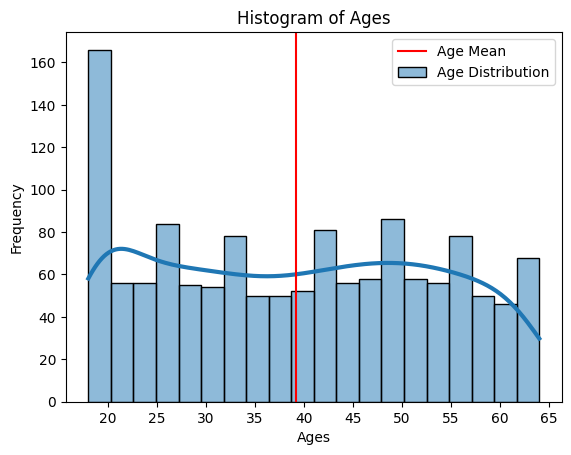

In [3]:
ageMean= df["age"].mean()
ageDeviation = df["age"].std()
x= ageMean - ageDeviation
y =ageMean + ageDeviation

plt.figure()
plt.grid(False)
sns.histplot(data=df, x="age", bins=20, edgecolor="black", kde=True,line_kws={"color": "purple", "linewidth": 3},label="Age Distribution")
plt.xticks(range(20,66,5))
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.axvline(x=ageMean, color="red",label="Age Mean")
plt.legend()
plt.title("Histogram of Ages")
plt.show()

<h4 align="center">1.1.2 Ages histogram by sex </h4>
<p> as you can see below, the difference between male and female ages are similar, having roughly the same amount of data for both cathegories

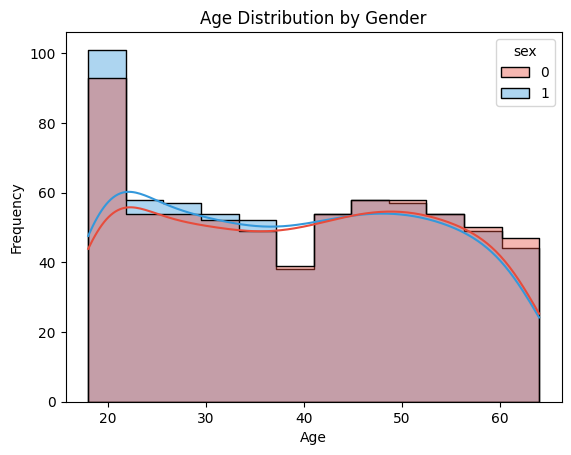

In [4]:
plt.figure()
plt.grid(False)
sns.histplot(data=df, x="age", hue="sex",edgecolor = "black", kde=True, palette={1: "#3498db", 0: "#e74c3c"}, alpha=0.4, element="step")
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

<h4 align="center">1.1.3 Ages of smokers vs non smokers </h4>
<p>

<Figure size 640x480 with 0 Axes>

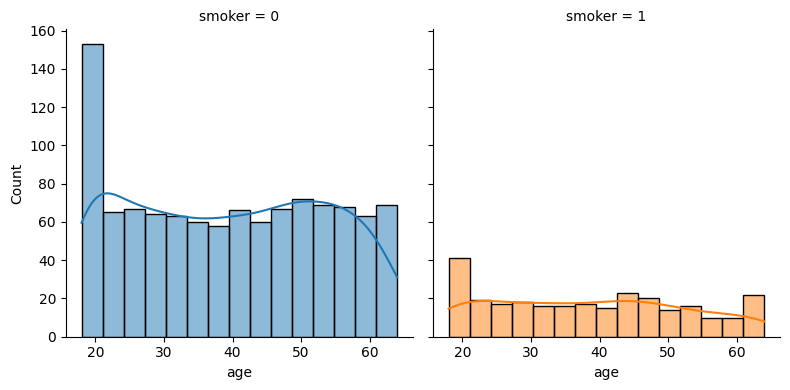

In [5]:
plt.figure()
g = sns.FacetGrid(df, col="smoker", hue="smoker", height=4, aspect=1)
g.map(sns.histplot, "age", kde=True,bins=15)

<h4 align="center">1.1.4 Ages of people from different regions </h4>
<p>

<Figure size 640x480 with 0 Axes>

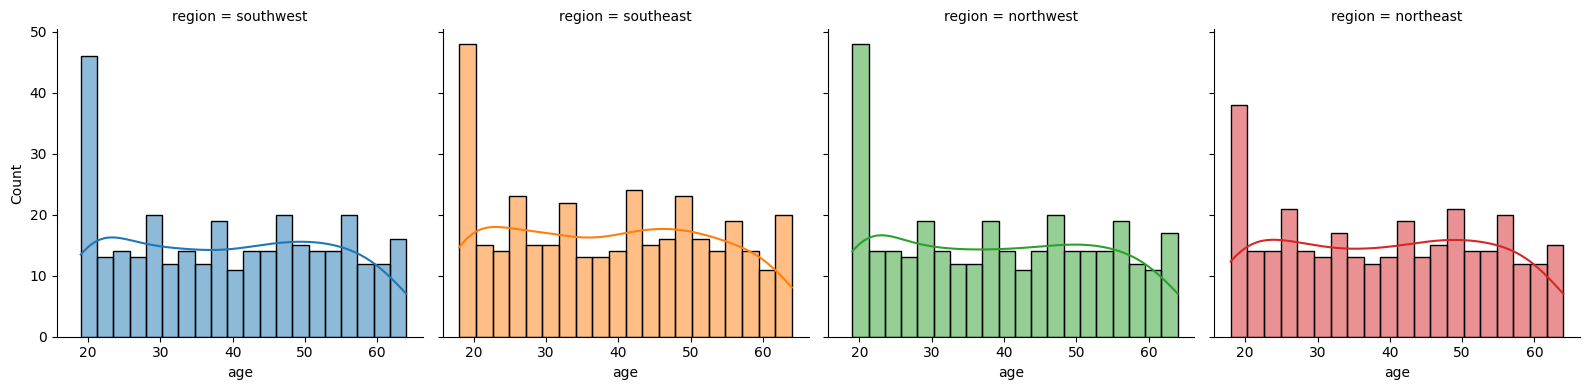

In [6]:
plt.figure()
g = sns.FacetGrid(df, col="region", hue="region", height=4, aspect=1)
g.map(sns.histplot, "age", kde=True,bins = 20)
# meanSW = df.loc[df['region'] == 'southwest', 'age'].mean()
# print(meanSW)

<h2 align="center">1.2 BMI graphics </h2>

<h4 align="center">1.2.1 histogram of BMI s </h4>

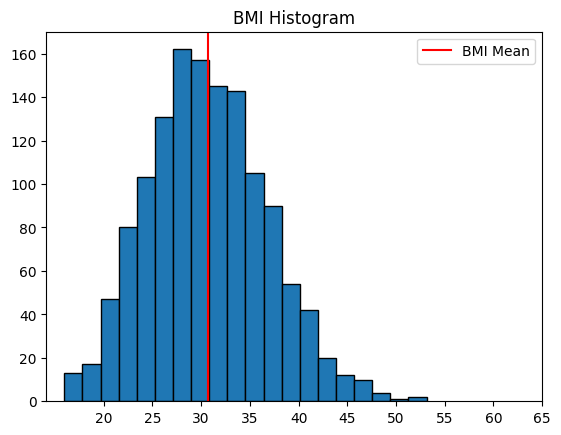

In [7]:
plt.figure()
plt.grid(False)
bmiMean= df["bmi"].mean()
plt.hist(df["bmi"],bins = 20,edgecolor="black")
plt.xticks(range(20,66,5))
plt.title("BMI Histogram")
plt.axvline(x=bmiMean, color="red",label="BMI Mean")
plt.legend()

<h4 align="center">1.2.2 Histogram of bmi by sex</h4>

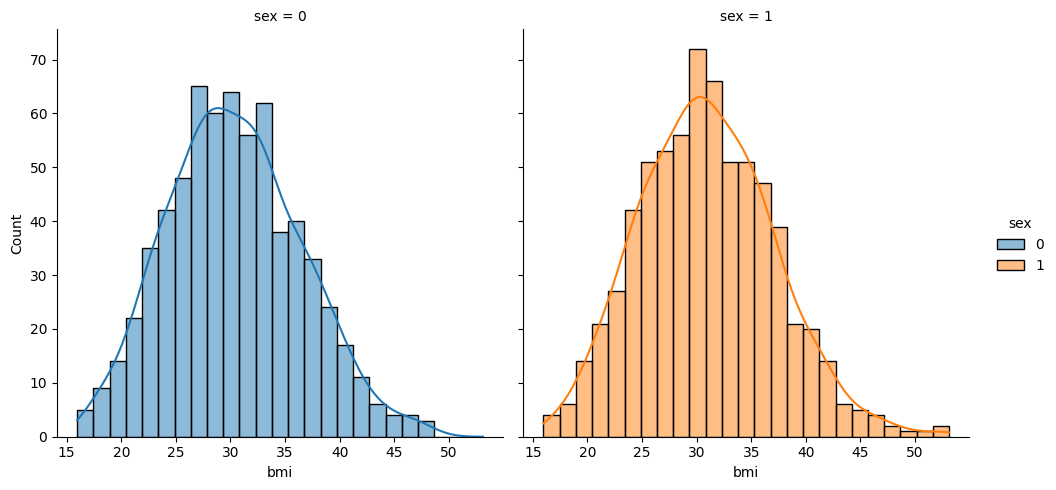

In [8]:
g = sns.displot(data = df, x = "bmi", col = "sex",hue ="sex", kind= "hist", kde = True, aspect=1)

<h4 align="center">1.2.3 Histogram of bmi by smoker status</h4>

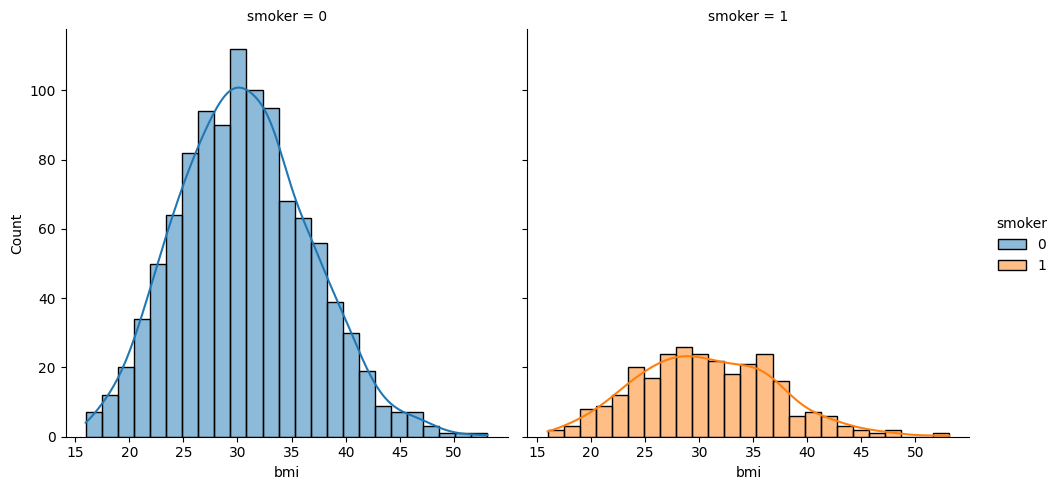

In [9]:
g = sns.displot(data = df, x = "bmi", col = "smoker",hue ="smoker", kind= "hist", kde = True, aspect=1)

<h4 align="center">1.2.4 Histogram of bmi by charges</h4>

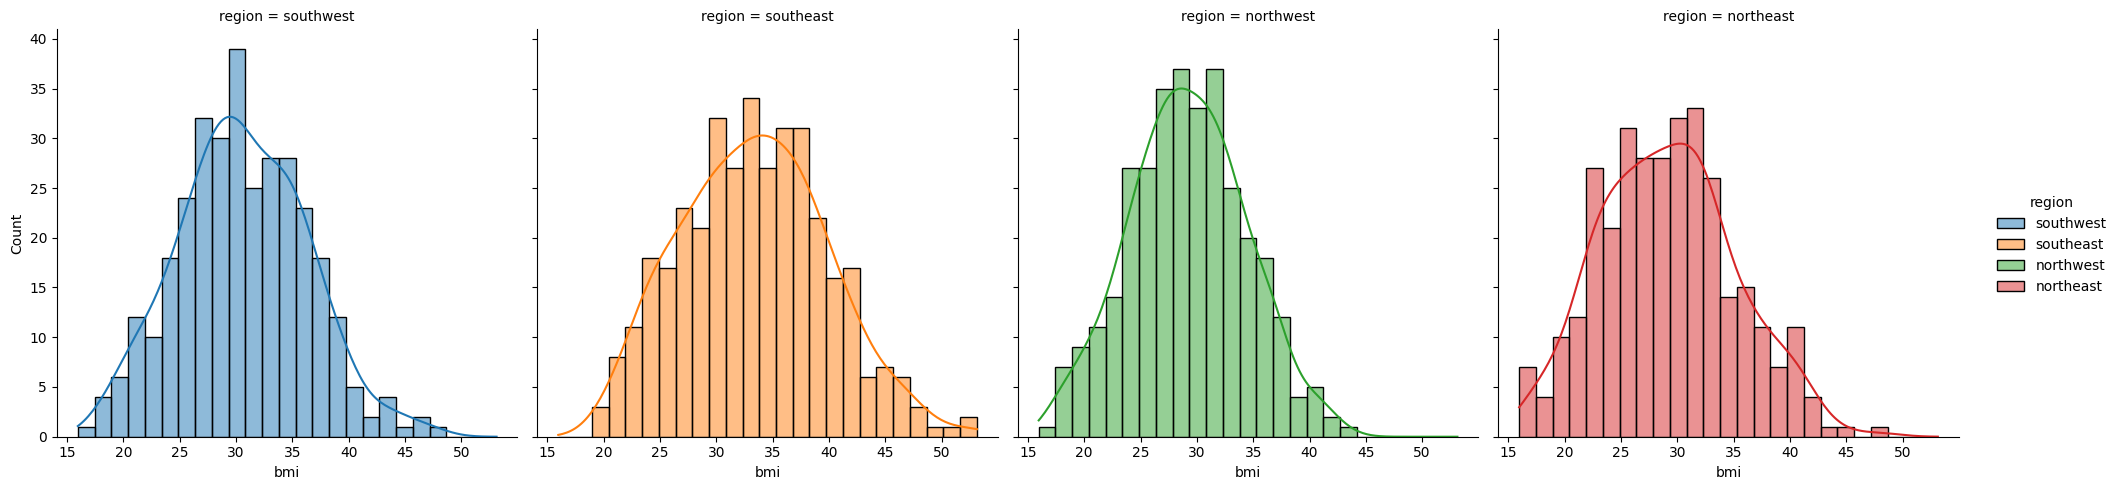

In [10]:
# g = sns.FacetGrid(df, col="region", aspect=1)
# g.map(sns.histplot, "bmi", kde=True)
# g.set(xticks= range(20,66,5))
g = sns.displot(data = df,x="bmi",col="region",hue="region",kind="hist",kde=True,aspect=1)
plt.show()


<h2 align="center">1.3 charges graphics</h2>

<h4 align = "center">1.3.1 Histogram of charges </h4>

Text(0.5, 1.0, 'Histogram of Charges')

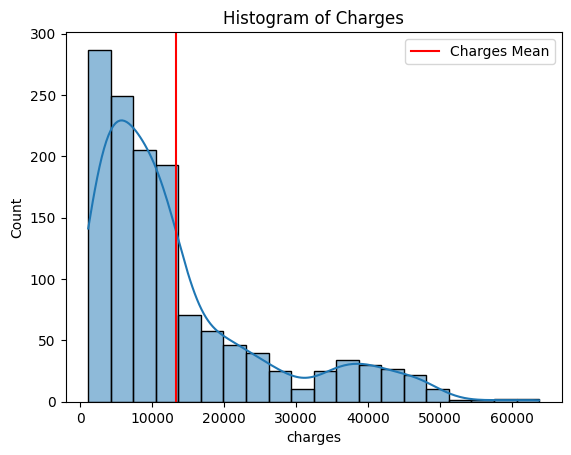

In [11]:
plt.figure()
plt.grid(False)
sns.histplot(data = df, x = "charges", bins = 20, edgecolor = "black", kde = True)
chargeMean = np.mean(df["charges"])
plt.axvline(x=chargeMean, color="red",label="Charges Mean")
plt.legend()
plt.title("Histogram of Charges")

<h4 align = "center">1.3.2 Histogram of charges by sex </h4>

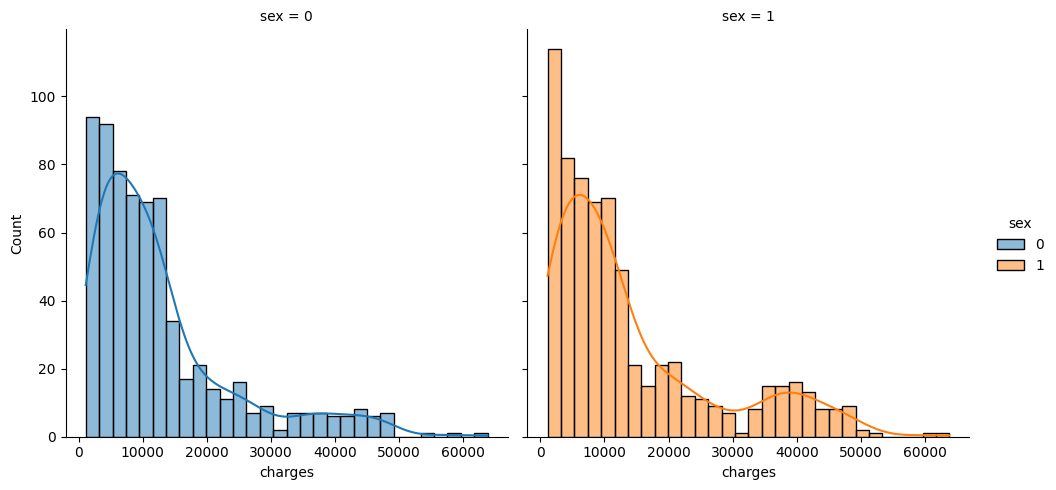

In [12]:
g= sns.displot(data = df, x = "charges",col = "sex", hue="sex", kind="hist", kde=True, aspect=1)

<h4 align = "center">1.3.3 Histogram of charges by smoker status </h4>

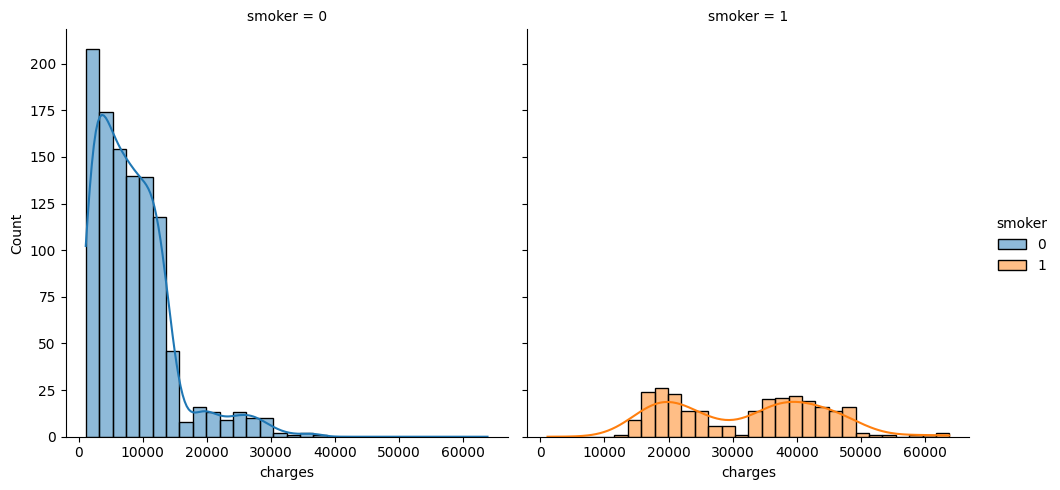

In [13]:
g= sns.displot(data = df, x = "charges",col = "smoker", hue="smoker", kind="hist", kde=True, aspect=1)

<h4 align = "center">1.3.4 Histogram of charges by region </h4>

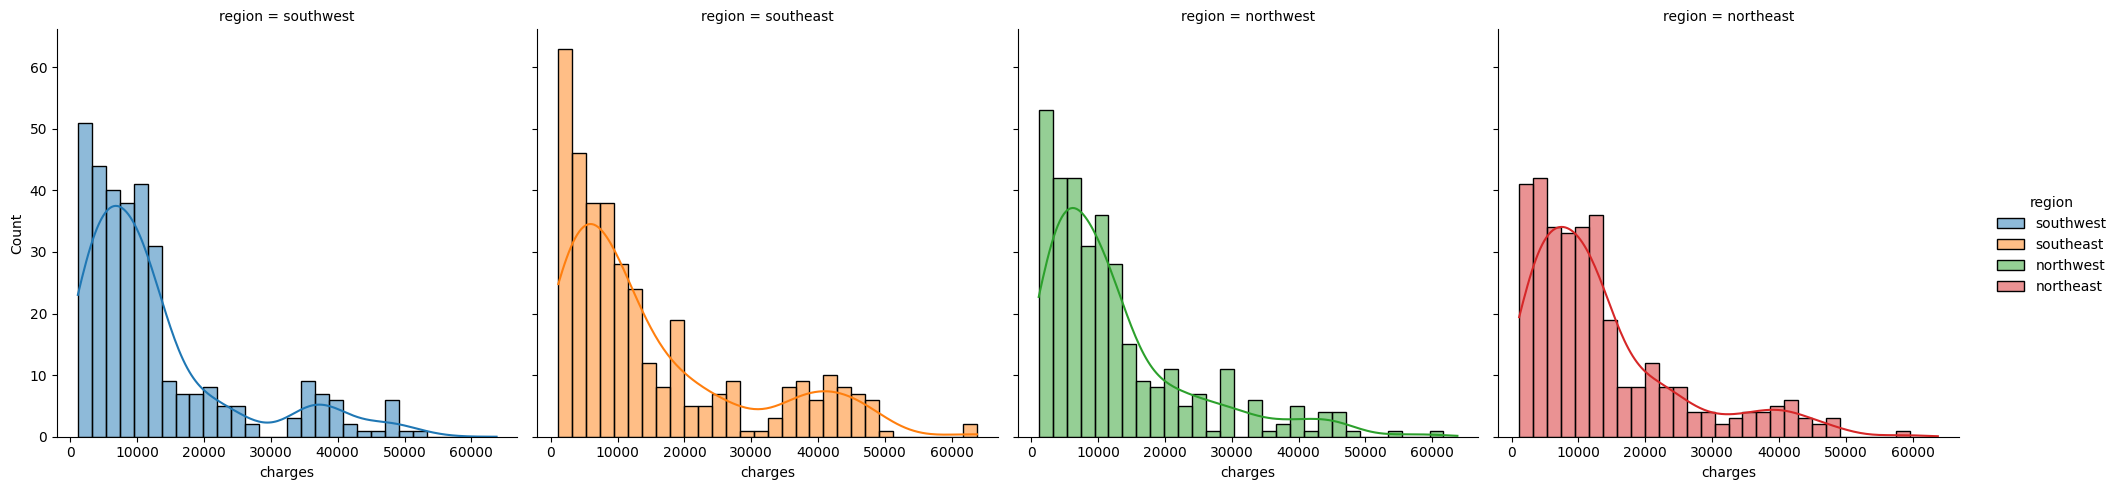

In [14]:
g = sns.displot(data = df, x="charges",col="region", hue="region", kind="hist", kde=True, aspect=1)

<h2 align = "center"> 2 Relationships between data </h2>
<p> this section is dedicated to the visualisations of the datapoints, how datapoints are scattered, what data has meaningful correlations etc

<h4 align = "center"> 2.1 Correlation heatmap </h4>
here we will get the R value of each intersection using Pearson s correlation

<Axes: >

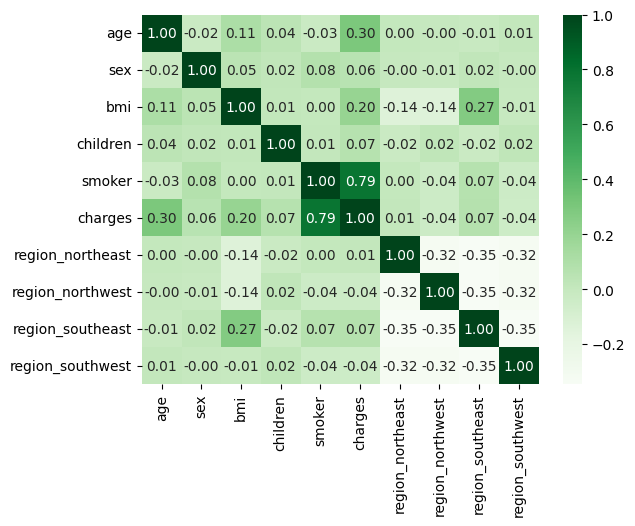

In [15]:
df = pd.get_dummies(df, columns=['region'], prefix='region')
corr= df.corr()
sns.heatmap(corr, annot=True,fmt=".2f", cmap="Greens")

<h4 align = "center"> 2.2 Scatterplot of bmi and age</h4>
<p> shows the different points between age and bmi, we observe a very large amount of uneven residual spread, making my prediction interval very wide, despite seeming homoscedastic the data has very little value due to a very low R2

The correlation coefficient (r) is: 0.109
The r squared is: 0.012


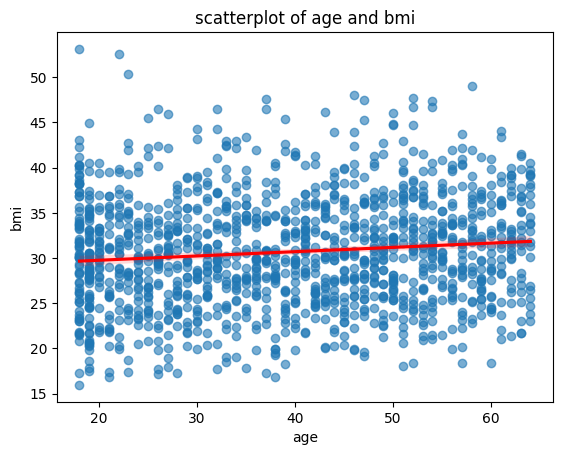

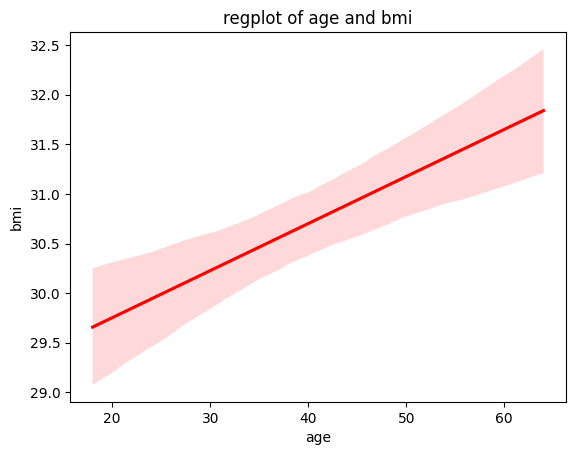

In [16]:
plt.figure()
sns.regplot(data=df, x="age", y="bmi", scatter_kws={'alpha':0.6},line_kws={"color": "red"})
plt.title("scatterplot of age and bmi")
plt.figure()
sns.regplot(data=df, x="age", y="bmi", scatter = False,line_kws={"color": "red"})
plt.title("regplot of age and bmi")
corr_val = df["age"].corr(df["bmi"])
print(f"The correlation coefficient (r) is: {corr_val:.3f}")
r_square = corr_val**2
print(f"The r squared is: {r_square:.3f}")

<h4 align = "center"> 2.3 Scatterplot of bmi and southwest</h4>
<p> this graph will just show you there is a difference between the means of the southeasteners and the other people in the dataset

The correlation coefficient (r) is: 0.109
The R squared is: 0.012


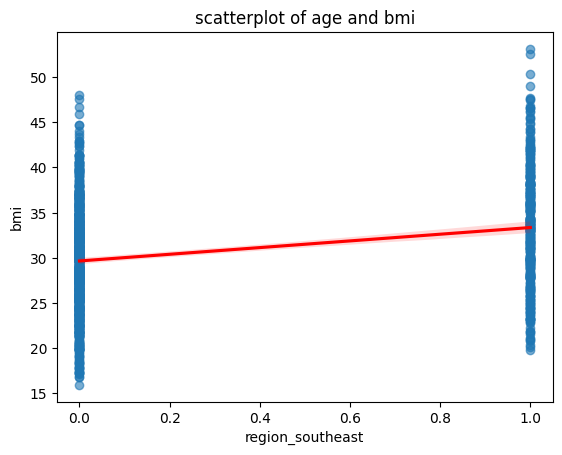

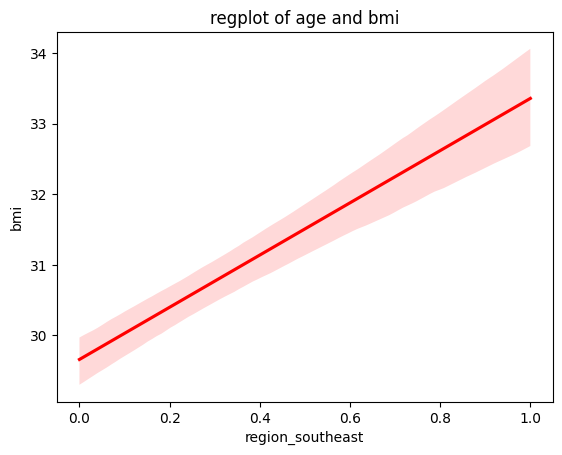

In [17]:
plt.figure()
sns.regplot(data=df, x="region_southeast", y="bmi", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})
plt.title("scatterplot of age and bmi")
plt.figure()
sns.regplot(data=df, x="region_southeast", y="bmi", scatter=False, line_kws={"color": "red"})
plt.title("regplot of age and bmi")
corr_val = df["age"].corr(df["bmi"])
R2 = corr_val**2
print(f"The correlation coefficient (r) is: {corr_val:.3f}")
print(f"The R squared is: {R2:.3f}")

<h4 align = "center"> 2.4 scatterplot of charges and bmi</h4>
<p> so, as you can see below, the R2 of non smokers bmis is 0.007, we can safely assume that the charges of a non smoker are not caused by bmi increase</p>
<p> the smoker situation on the other hand is much different, having an r2 of 0.65 compared to the non smokers of below 0.01, bmis seem to have a much bigger impact on charges for smokers, it is likely that charges are influenced by bmi

The correlation coefficient between smokers bmis and charges(r) is: 0.806
The R squared is: 0.650
The correlation coefficient between non smokers bmis and charges(r) is: 0.084
The R squared is: 0.007


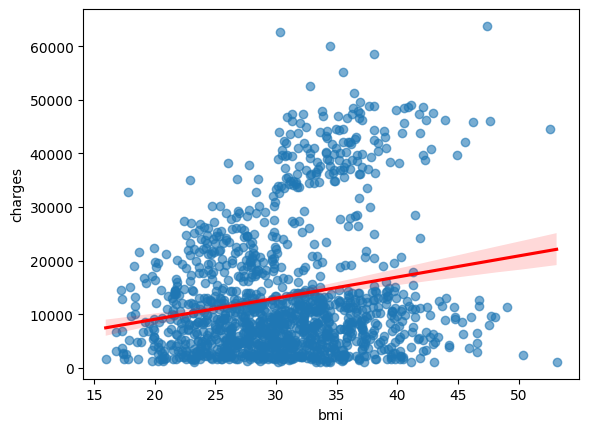

<Figure size 640x480 with 0 Axes>

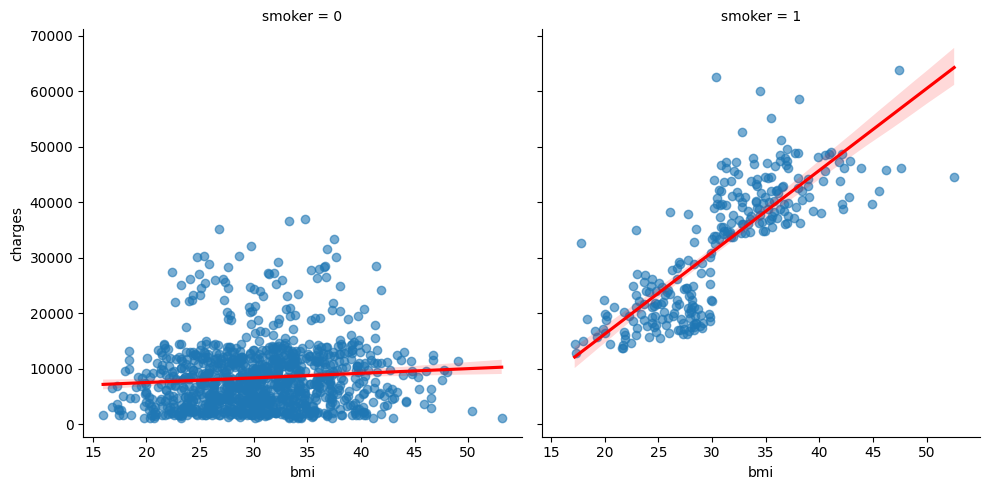

In [18]:
plt.figure()
sns.regplot(data=df, x="bmi", y="charges", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})

plt.figure()
sns.lmplot(data=df, x="bmi", y="charges",col="smoker", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})

smoker = df[df["smoker"] == 1]
corr_val = smoker["bmi"].corr(smoker["charges"])
r2 = corr_val ** 2
nonsmoker = df[df["smoker"] == 0]
corr_val2 = nonsmoker["bmi"].corr(nonsmoker["charges"])
r22 = corr_val2 ** 2
print(f"The correlation coefficient between smokers bmis and charges(r) is: {corr_val:.3f}")
print(f"The R squared is: {r2:.3f}")
print(f"The correlation coefficient between non smokers bmis and charges(r) is: {corr_val2:.3f}")
print(f"The R squared is: {r22:.3f}")


<h4 align = "center" > 2.5 Age and charges scatterplot </h4>
<p> as we can see aging for smokers is not the main cause of charge increments, since the R2 of smoker charges by age is quite small having 0.13
<p> on the other hand, age does a much better job at explaining why non smokers charges increase even with varying bmis

<Figure size 640x480 with 0 Axes>

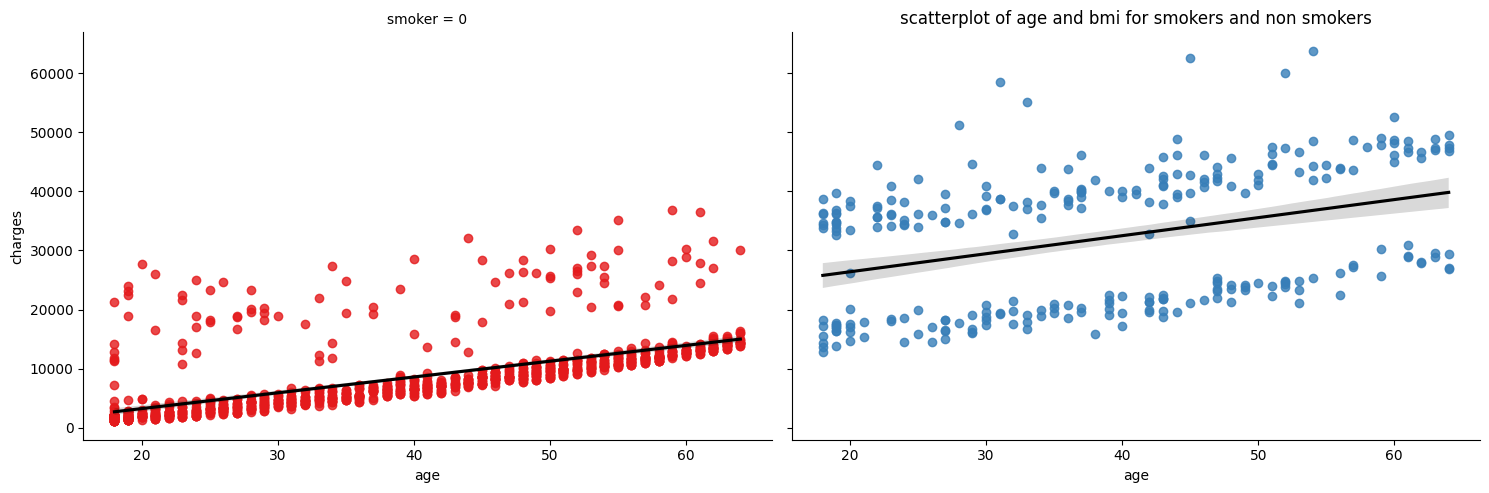

The correlation coefficient between smokers ages and charges(r) is: 0.368
The R squared is: 0.136
The correlation coefficient between non smokers ages and charges(r) is: 0.628
The R squared is: 0.394


In [19]:
plt.figure()
sns.lmplot(data=df, x="age", y="charges", hue="smoker", col="smoker", palette="Set1", aspect=1.5,
           line_kws={"color": "black"})
plt.title("scatterplot of age and bmi for smokers and non smokers")
plt.show()

smoker = df[df["smoker"] == 1]
corr_val = smoker["age"].corr(smoker["charges"])
r2 = corr_val ** 2
nonsmoker = df[df["smoker"] == 0]
corr_val2 = nonsmoker["age"].corr(nonsmoker["charges"])
r22 = corr_val2 ** 2
print(f"The correlation coefficient between smokers ages and charges(r) is: {corr_val:.3f}")
print(f"The R squared is: {r2:.3f}")
print(f"The correlation coefficient between non smokers ages and charges(r) is: {corr_val2:.3f}")
print(f"The R squared is: {r22:.3f}")

<h4 align = "center"> 2.6 Charges by age for each location </h4>
<p> we can see each of the 4 region has an R2 ranging from 0.06 to 0.11, whilst not the best values I will still try to incorporate them into predictions </p>

0.25835787760143436 0.06674879291871774
0.31059315928465775 0.09646811059442478
0.3376538424947998 0.11401011735150307
0.3009512000834591 0.09057162483167423


<Figure size 640x480 with 0 Axes>

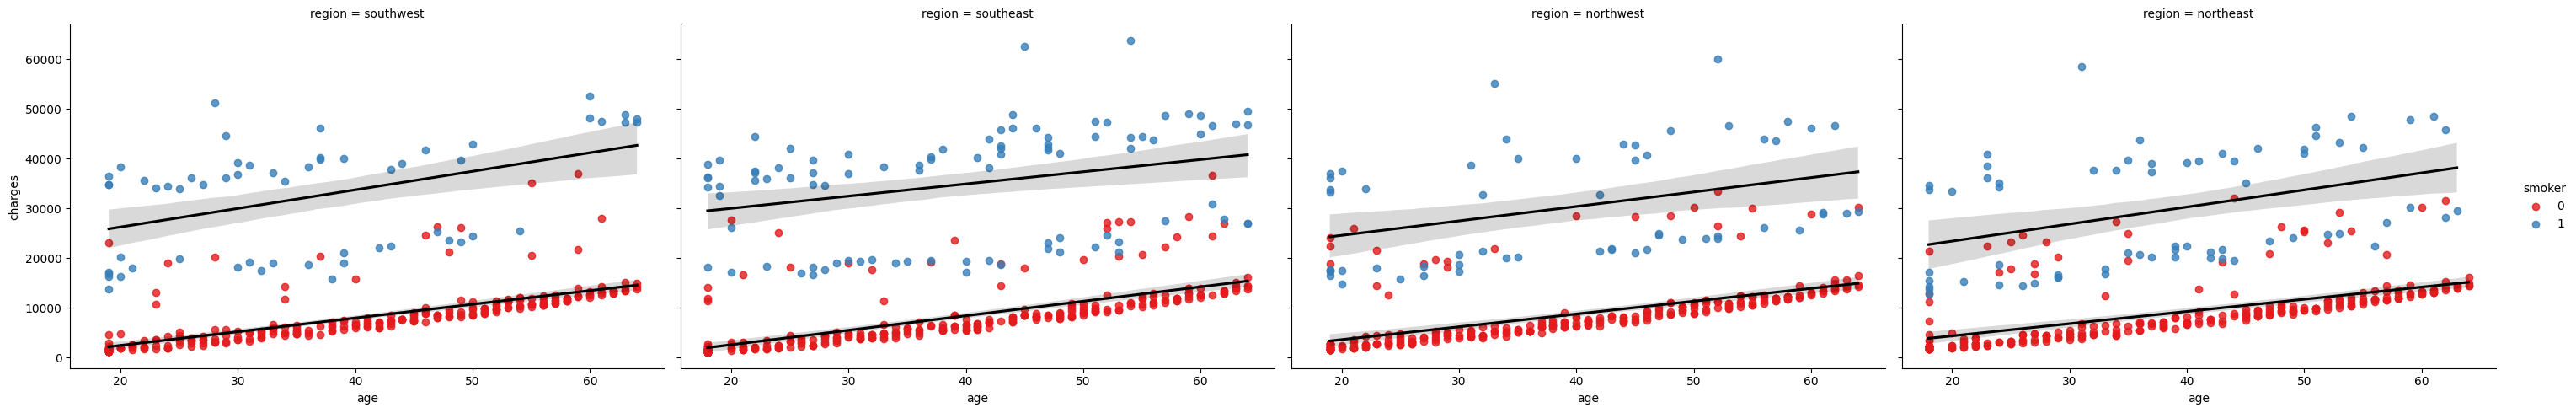

In [20]:
#here we are using df2 because we need the data without dummies

plt.figure()
sns.lmplot(data = df2, x = "age", y = "charges", hue = "smoker", col = "region", palette="Set1", aspect=1.5,line_kws={"color": "black"})

sw = df[df["region_southwest"] == True]
corr_valsw = sw["age"].corr(sw["charges"])
r2sw = corr_valsw ** 2
print(corr_valsw,r2sw)

se = df[df["region_southeast"] == True]
corr_val = se["age"].corr(se["charges"])
r2 = corr_val ** 2
print(corr_val,r2)

nw = df[df["region_northwest"] == True]
corr_valnw = nw["age"].corr(nw["charges"])
r2nw = corr_valnw ** 2
print(corr_valnw,r2nw)

ne = df[df["region_northeast"] == True]
corr_valne = ne["age"].corr(ne["charges"])
r2ne = corr_valne ** 2
print(corr_valne,r2ne)



0.7214008260577199
32458.52589230331
8603.22107564026


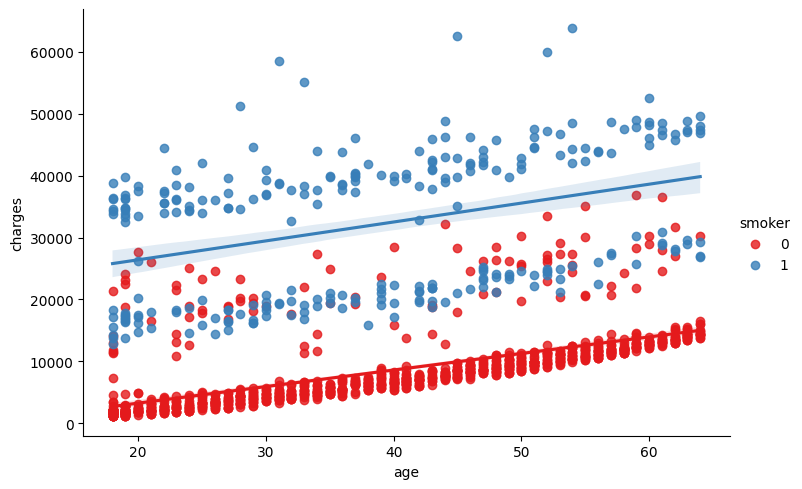

In [21]:
from sklearn.linear_model import LinearRegression

X = df[['age', 'smoker']]
y = df['charges']

model = LinearRegression()
model.fit(X, y)

R2_1= model.score(X, y)
print(R2_1)

testData1 = pd.DataFrame([[40, 1],[40,0]], columns=['age', 'smoker'])
test1 = model.predict(testData1)
print(test1[0])
print(test1[1])

sns.lmplot(data=df, x="age", y="charges", hue="smoker", palette="Set1", aspect=1.5)



In [22]:
print(df)
x = X = df[['age', 'smoker','sex','bmi',]]
y = df['charges']

model2 = model = LinearRegression()
model.fit(X, y)

R2_2 = model.score(X, y)
print(R2_2)
testData = pd.DataFrame([[40, 1, 1, 30],[40,0,1,30]], columns=['age', 'smoker', 'sex', 'bmi'])
test = model.predict(testData)
print(test[0])
print(test[1])
#,['40','0','1','30']

      age  sex     bmi  children  smoker      charges  region_northeast  \
0      19    0  27.900         0       1  16884.92400             False   
1      18    1  33.770         1       0   1725.55230             False   
2      28    1  33.000         3       0   4449.46200             False   
3      33    1  22.705         0       0  21984.47061             False   
4      32    1  28.880         0       0   3866.85520             False   
...   ...  ...     ...       ...     ...          ...               ...   
1333   50    1  30.970         3       0  10600.54830             False   
1334   18    0  31.920         0       0   2205.98080              True   
1335   18    0  36.850         0       0   1629.83350             False   
1336   21    0  25.800         0       0   2007.94500             False   
1337   61    0  29.070         0       1  29141.36030             False   

      region_northwest  region_southeast  region_southwest  
0                False             Fal

the R2 difference between my first regression where I estimate based on age and if they smoke or not and the second one where i also consider their sex and bmi is small
first reg R2 = 0.7214008260577199
second reg R2 = 0.7474972680928911
in .3f the difference is 0.026, this I can confidently say the bmi and sex do not influence charges a lot, even tho my correlation for bmi and charges is 0.1

In [23]:
df5 = pd.get_dummies(df5, columns=['region'], prefix='region')

df5['bmi_smoker'] = df5['bmi'] * df5['smoker']

# Update your features list to include this new power-variable
features = ['age', 'smoker', 'sex', 'bmi', 'bmi_smoker',
            'region_northwest', 'region_southeast', 'region_southwest',"region_northeast", 'children']

X = df5[features]
y = df5['charges']

model = LinearRegression()
model.fit(X, y)

print(f"R2 Score: {model.score(X, y)}")

test_rows = [
    [40, 1, 1, 30, 30, 0, 0, 1,0, 5],
    [40, 0, 1, 30, 0, 0, 0, 0,1, 0]
]

testData = pd.DataFrame(test_rows, columns=features)

predictions = model.predict(testData)
print(f"Southwest Smoker Prediction: {predictions[0]}")
print(f"Northeast Non-Smoker Prediction: {predictions[1]}")



R2 Score: 0.8409179940508522
Southwest Smoker Prediction: 32755.384854973294
Northeast Non-Smoker Prediction: 8527.194786303418


In [24]:

df6 = pd.get_dummies(df6, columns=['region'], prefix='region',drop_first=True)

features = ['age', 'smoker', 'sex', 'bmi', 'region_northwest', 'region_southeast', 'region_southwest','children']

X = df6[features]
y = df6['charges']

model = LinearRegression()
model.fit(X, y)

print(f"R2 Score: {model.score(X, y)}")

test_rows = [
    [40, 1, 1, 30, 0, 0, 1, 5],
    [40, 0, 1, 30, 0, 0, 0, 0]
]

testData = pd.DataFrame(test_rows, columns=features)

predictions = model.predict(testData)
print(f"Southwest Smoker Prediction: {predictions[0]}")
print(f"Northeast Non-Smoker Prediction: {predictions[1]}")
print(model.coef_)

R2 Score: 0.7509130345985205
Southwest Smoker Prediction: 33646.19105061439
Northeast Non-Smoker Prediction: 8380.204774256814
[  256.85635254 23848.53454191  -131.3143594    339.19345361
  -352.96389942 -1035.02204939  -960.0509913    475.50054515]


In [25]:
df7 = pd.get_dummies(df7, columns=['region'], prefix='region')
features = ['age', 'smoker', 'sex', 'bmi', 'region_northwest', 'region_southeast', 'region_southwest',"region_northeast",'children']

X = df7[features]
y = df7['charges']

model = LinearRegression()
model.fit(X, y)

print(f"R2 Score: {model.score(X, y)}")

test_rows = [
    [40, 1, 1, 30, 0, 0, 1,0, 5],
    [40, 0, 1, 30, 0, 0, 0,1, 0]
]

testData = pd.DataFrame(test_rows, columns=features)

predictions = model.predict(testData)
print(f"Southwest Smoker Prediction: {predictions[0]}")
print(f"Northeast Non-Smoker Prediction: {predictions[1]}")
print(model.coef_)

R2 Score: 0.7509130345985205
Southwest Smoker Prediction: 33646.191050614434
Northeast Non-Smoker Prediction: 8380.204774256807
[  256.85635254 23848.53454191  -131.3143594    339.19345361
   234.0453356   -448.01281436  -373.04175627   587.00923503
   475.50054515]


               age        bmi
cluster                      
0        49.831522  26.748043
1        52.490625  36.406406
2        26.872611  35.189729
3        26.446429  25.252143


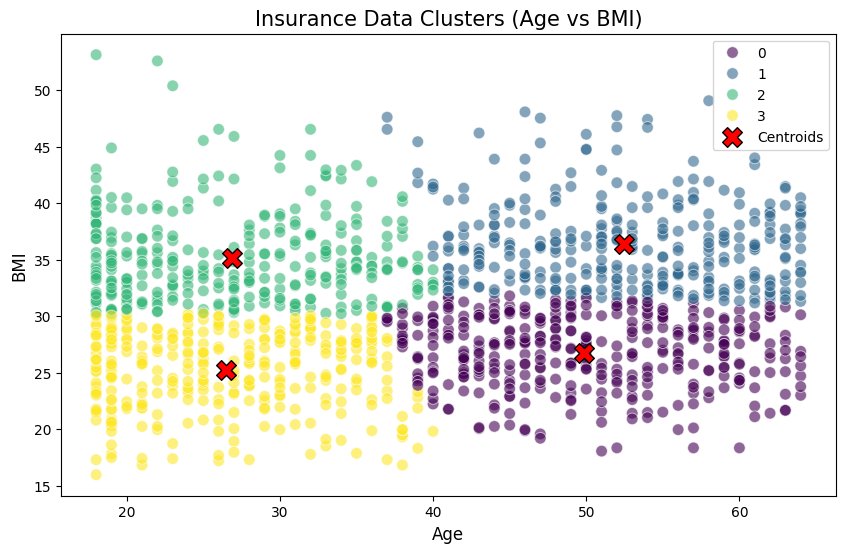

In [26]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ["age", "bmi"]
X = df[features]

# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Clustering
kmeans = KMeans(n_clusters=4, n_init="auto", random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Print results
print(df.groupby('cluster')[features].mean())

# 5. Visualization (Age vs BMI)
plt.figure(figsize=(10, 6))

# Plotting Age vs BMI because these are your actual features
sns.scatterplot(data=df, x='age', y='bmi', hue='cluster', palette='viridis', s=70, alpha=0.6)

# 6. Get the centroids back to original scale
# Index 0 = age, Index 1 = bmi, Index 2 = smoker_val
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Plot the centroids using Age (index 0) and BMI (index 1)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='red', marker='X', s=200, label='Centroids', edgecolors='black')

plt.title('Insurance Data Clusters (Age vs BMI)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.legend()
plt.show()



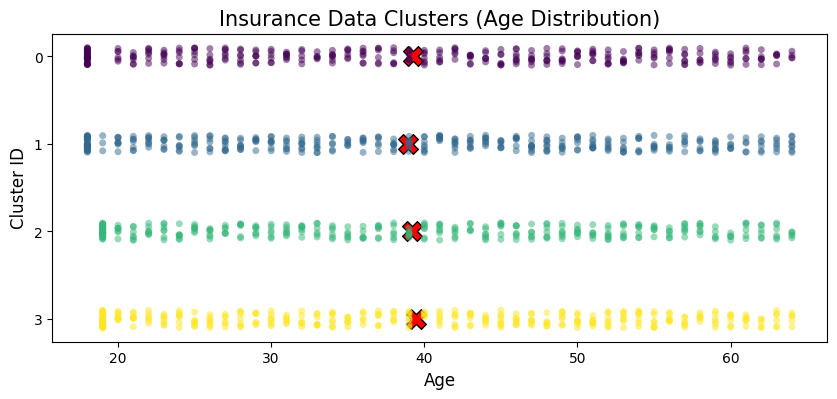

--- Cluster Profiles (Means of all features) ---
               age  region_northwest  region_southeast  region_southwest  \
cluster                                                                    
0        39.268519               0.0               0.0               0.0   
1        38.939560               0.0               1.0               0.0   
2        39.196923               1.0               0.0               0.0   
3        39.455385               0.0               0.0               1.0   

         region_northeast  
cluster                    
0                     1.0  
1                     0.0  
2                     0.0  
3                     0.0  


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df2 = pd.get_dummies(df2, columns=['region'], prefix='region')
# 1. Setup Features (BMI is gone)
feautures2 = ["age", "region_northwest", "region_southeast", "region_southwest", "region_northeast"]
Y = df2[feautures2]

# 2. Scaling
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y)

# 3. Clustering
kmeans = KMeans(n_clusters=4, n_init="auto", random_state=42)
df2['cluster'] = kmeans.fit_predict(Y_scaled)

# 4. Visualization (Age Scatterplot - Ignoring BMI)
plt.figure(figsize=(10, 4))

# We plot Age on X, and Cluster on Y to see the age distribution of each group
sns.stripplot(data=df2, x='age', y='cluster', hue='cluster',
              palette='viridis', orient='h', size=5, alpha=0.5, legend=False)

# 5. Centroids (Back to original scale)
# Since 'age' is index 0 in your feautures2 list:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], range(4),
            c='red', marker='X', s=200, label='Age Centroids', edgecolors='black')

plt.title('Insurance Data Clusters (Age Distribution)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.show()

# 6. Print Results
print("--- Cluster Profiles (Means of all features) ---")
print(df2.groupby('cluster')[feautures2].mean())

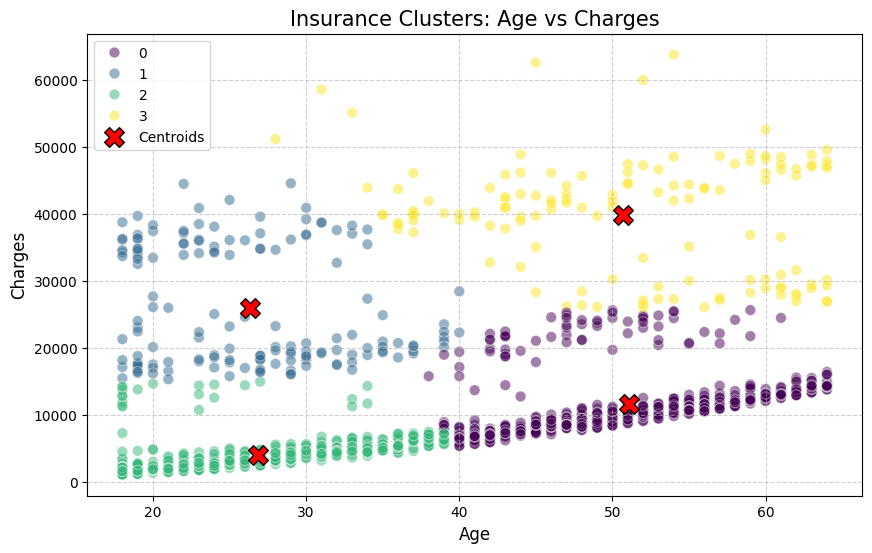

--- Cluster Profiles ---
               age       charges
cluster                         
0        51.082734  11664.536743
1        26.342105  25994.596050
2        26.825301   4129.751867
3        50.712121  39867.784333


In [28]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Setup Features
features3 = ["age", "charges"]
Z = df3[features3]

# 2. Scaling
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z)

# 3. Clustering
kmeans = KMeans(n_clusters=4, n_init="auto", random_state=42)
df3['cluster'] = kmeans.fit_predict(Z_scaled)

# 4. Visualization (Age vs Charges)
plt.figure(figsize=(10, 6))

# FIX: Use scatterplot instead of stripplot for continuous data like 'charges'
sns.scatterplot(data=df3, x='age', y='charges', hue='cluster',
                palette='viridis', s=60, alpha=0.5)

# 5. Centroids (Back to original scale)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

# FIX: Plot Y as centroids_original[:, 1] (Charges) so they line up with the dots
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='red', marker='X', s=200, label='Centroids', edgecolors='black', zorder=10)

plt.title('Insurance Clusters: Age vs Charges', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Print Results
print("--- Cluster Profiles ---")
print(df3.groupby('cluster')[features3].mean())

In [29]:
!git commit -m "Updating lab results"

'git' is not recognized as an internal or external command,
operable program or batch file.
